<a href="https://colab.research.google.com/github/kobayashi-2000/retail-sales-analysis/blob/main/retail_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

with zipfile.ZipFile("SampleSuperstore.csv.zip", "r") as z:
    z.extractall(".")
    print(z.namelist())

['SampleSuperstore.csv']


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")
print(f"表格基礎資料為:{df.shape}")
print(df.columns.tolist())
df.head()

engine = create_engine("sqlite:///superstore.db")
df.to_sql("superstore", engine, if_exists="replace", index=False)
print("SQL資料庫建立完成！")


表格基礎資料為:(9994, 13)
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']
SQL資料庫建立完成！


In [3]:
print(f"總訂單數:{df.shape[0]}")
print(f"欄位數:{df.shape[1]}")

print("將各欄位空值情形整理如下:")
print(df.isnull().sum())
#確認有沒有空值
print(df[["Sales","Profit","Discount"]].describe())

總訂單數:9994
欄位數:13
將各欄位空值情形整理如下:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
              Sales       Profit     Discount
count   9994.000000  9994.000000  9994.000000
mean     229.858001    28.656896     0.156203
std      623.245101   234.260108     0.206452
min        0.444000 -6599.978000     0.000000
25%       17.280000     1.728750     0.000000
50%       54.490000     8.666500     0.200000
75%      209.940000    29.364000     0.200000
max    22638.480000  8399.976000     0.800000


## 1. 資料概覽

本分析使用 Kaggle 上的 Sample Superstore 銷售資料集。
資料共包含 **9,994 筆訂單**、**13 個欄位**，涵蓋地區、品類、銷售額、利潤等資訊。
經檢查後確認**無任何空值**，資料品質良好，可直接進行分析。

**基本統計摘要：**
- 平均每筆訂單銷售額：$229

- 平均每筆訂單利潤：$28

- 最大單筆虧損：-$6,599

- 最大單筆利潤：$8,399

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


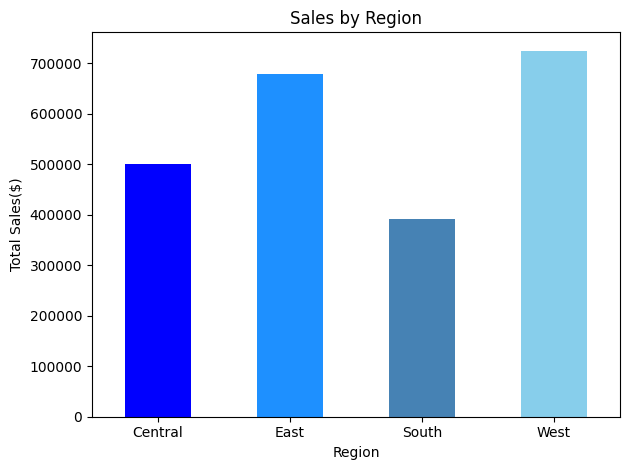

In [4]:
df_region=df.groupby("Region")["Sales"].sum()
print(df_region)

df_region.plot(kind="bar",title="Sales by Region",
    color=["blue","dodgerblue","steelblue","skyblue"])

plt.xlabel("Region")
plt.ylabel("Total Sales($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. 地區銷售分析

經群組分析比較各地區總銷售額，結果如下：

- **West** 地區銷售額最高，達 **$725,457**

- **East** 地區緊追在後，銷售額為 **$678,781**

- **Central** 地區銷售額為 **$501,239**

- **South** 地區表現最弱，銷售額僅 **$391,721**

West 與 South 的銷售差距將近一倍，顯示各地區業績表現落差明顯，建議針對 South 地區進行市場策略調整。

In [5]:
df_region_sql = pd.read_sql("""
    SELECT Region, ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", engine)
print(df_region_sql)

    Region  Total_Sales
0     West    725457.82
1     East    678781.24
2  Central    501239.89
3    South    391721.91


*以上結果使用 SQL 查詢驗證，與 pandas groupby 分析結果一致。*

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


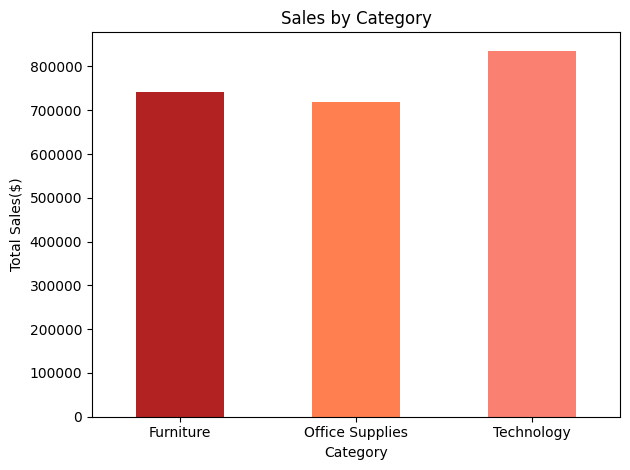

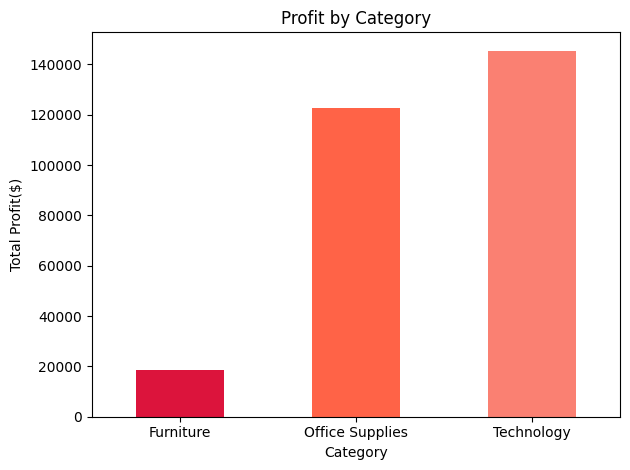

In [6]:
print(df["Category"].value_counts()) #確認共有幾種品項需要分析

print(df.groupby("Category")[["Sales","Profit"]].sum())

df_sales=df.groupby("Category")["Sales"].sum()
df_profit=df.groupby("Category")["Profit"].sum()

df_sales.plot(kind="bar",title="Sales by Category",color=["firebrick", "coral", "salmon"])
plt.xlabel("Category")
plt.ylabel("Total Sales($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df_profit.plot(kind="bar",title="Profit by Category",color=["crimson", "tomato", "salmon"])
plt.xlabel("Category")
plt.ylabel("Total Profit($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. 品項銷售分析

經群組分析比較各品項銷售額及利潤，就銷售額而言排序為
Technology > Furniture > Office Supplies，

然而利潤排序卻為 Technology > Office Supplies > Furniture。

- **Technology** 銷售額及利潤皆位居第一，分別為 **836,154** 及 **145,454**，
  是整體表現最佳的品類。

- **Office Supplies** 銷售額最低**719,047**，但利潤達 **122,490**，
  成本控制表現優異。

- **Furniture** 銷售額位居第二 **742,000**，利潤卻僅有 **18,451**，
  獲利率明顯偏低。

Furniture 高銷售卻低利潤的現象值得關注，建議檢討其折扣政策與成本結構，
避免持續以低利潤換取銷售額。

Region   Category       
Central  Furniture          -2871.0494
         Office Supplies     8879.9799
         Technology         33697.4320
East     Furniture           3046.1658
         Office Supplies    41014.5791
         Technology         47462.0351
South    Furniture           6771.2061
         Office Supplies    19986.3928
         Technology         19991.8314
West     Furniture          11504.9503
         Office Supplies    52609.8490
         Technology         44303.6496
Name: Profit, dtype: float64


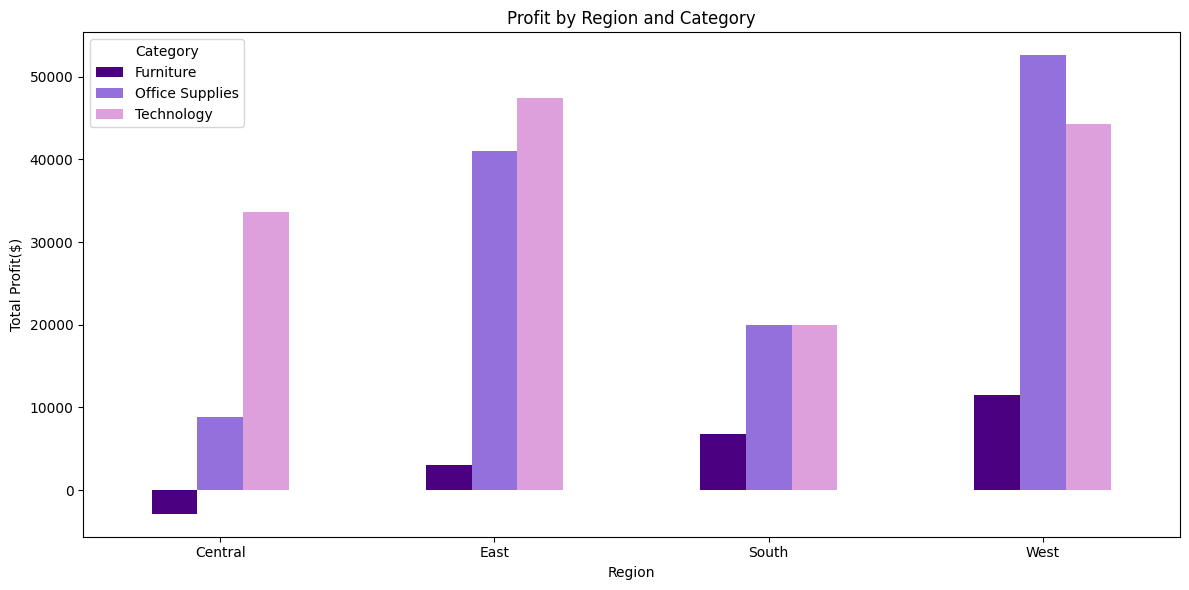

In [7]:
df_profit_by_region=df.groupby(["Region","Category"])["Profit"].sum()

print(df_profit_by_region)

df_profit_by_region.unstack().plot(
    kind="bar",
    title="Profit by Region and Category",
    figsize=(12,6),
    stacked=False,
    color=["indigo", "mediumpurple", "plum"]
    )
plt.xlabel("Region")
plt.ylabel("Total Profit($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. 地區+品項交叉分析

經交叉分析比較各地區之品項所帶來之利潤，可發現以下重點:


- **Central** 地區中，**Furniture** 系列品項整體呈現虧損，共 **-$2,871** ，是四個地區中唯一出現虧損的品項組合

- **West** 地區的**Office Supplies** 系列品項利潤高達 **$52,609** 是全資料集中單一地區系列品項利潤最高的。

- 同樣是 **Furniture** 系列,**West**地區利潤為**11,504**，而**Central**地區卻虧損**2,871**，差距達 **$14,375**，推測與各地區折扣策略差異有關。

- 整體而言，**West** 地區三種品項利潤加總最高，是表現最佳的地區。

- **South** 地區三種品項利潤皆偏低，與第二部分銷售額最低的結論一致，
  顯示 South 地區無論銷售或利潤表現皆需改善。


利潤為負的訂單共有:1871筆
虧損訂單佔整體訂單共:18.72%
Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Accessories     -930.6265
Fasteners        -33.1952
Name: Profit, dtype: float64


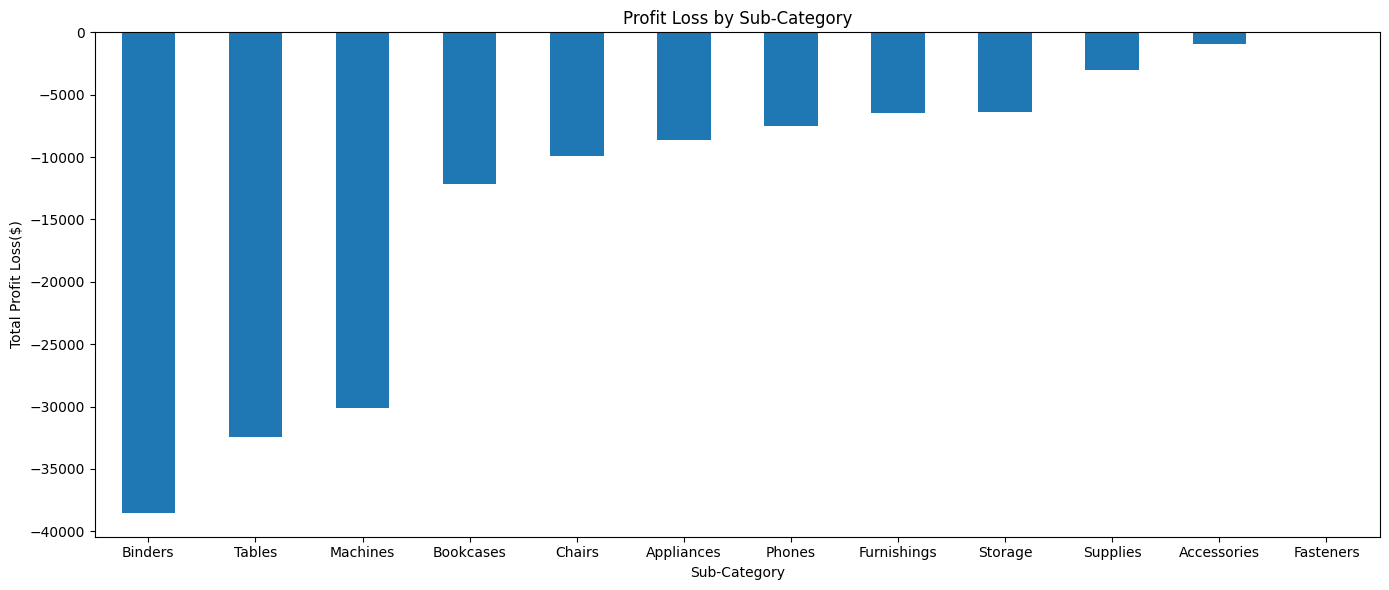

In [8]:
df_loss=df[df["Profit"]<0]

print(f"利潤為負的訂單共有:{df_loss.shape[0]}筆")
num_loss=len(df_loss)/len(df)*100
print(f"虧損訂單佔整體訂單共:{num_loss:.2f}%")

loss_by_sub=df_loss.groupby("Sub-Category")["Profit"].sum().sort_values()
print(loss_by_sub)

loss_by_sub.plot(
    kind="bar",
    title="Profit Loss by Sub-Category",
    figsize=(14,6),
)

plt.xlabel("Sub-Category")
plt.ylabel("Total Profit Loss($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
df_loss_sql = pd.read_sql("""
    SELECT "Sub-Category", ROUND(SUM(Profit), 2) AS Total_Loss
    FROM superstore
    WHERE Profit < 0
    GROUP BY "Sub-Category"
    ORDER BY Total_Loss ASC
""", engine)
print(df_loss_sql)

   Sub-Category  Total_Loss
0       Binders   -38510.50
1        Tables   -32412.15
2      Machines   -30118.67
3     Bookcases   -12152.21
4        Chairs    -9880.84
5    Appliances    -8629.64
6        Phones    -7530.62
7   Furnishings    -6490.91
8       Storage    -6426.30
9      Supplies    -3015.62
10  Accessories     -930.63
11    Fasteners      -33.20


*以上結果使用 SQL 查詢驗證，與 pandas groupby 分析結果一致。*

## 5. 虧損分析

根據上方圖表及結果可分析出以下結論:

- 虧損最多的物品為 **Binders**、**Tables**以及**Machines**，虧損金額分別為**USD** **-38,510** 、**USD** **-32,412** 及 **USD** **-30,118**

- 總虧損訂單共 1,871 筆，佔整體訂單的 18.7%，
  推測可能與折扣策略或成本結構有關，建議進一步分析折扣與利潤的相關性。

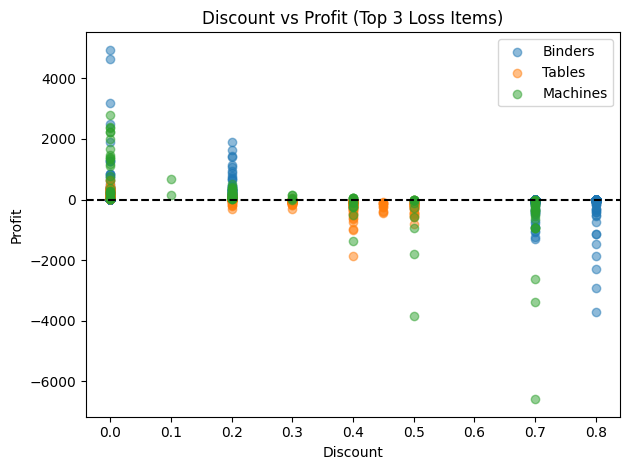

In [10]:
# 篩選這三個虧損最多的品項
top_loss = ["Binders", "Tables", "Machines"]
df_top_loss = df[df["Sub-Category"].isin(top_loss)]

# 散點圖：折扣 vs 利潤
for item in top_loss:
    data = df_top_loss[df_top_loss["Sub-Category"] == item]
    plt.scatter(data["Discount"], data["Profit"], label=item, alpha=0.5)

plt.axhline(y=0, color="black", linestyle="--")  # 零利潤線
plt.title("Discount vs Profit (Top 3 Loss Items)")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.legend()
plt.tight_layout()
plt.show()

## 6. 前三名虧損商品及折扣率分析

根據折扣與利潤散點圖分析，前三大虧損品項在折扣超過 40% 後利潤普遍轉為負值，顯示過高的折扣率是造成虧損的主要原因，建議將折扣上限控制在30% 以內。

值得注意的是，**Tables** 即使在無折扣的情況下利潤也偏低，
加入折扣後幾乎全面虧損，推測該商品本身定價或成本結構有問題，
不適合參與促銷活動，建議從成本面重新檢討定價策略。

## 總結

本分析針對 Superstore 銷售資料，探討各地區、品項的銷售額、利潤及折扣率之趨勢，主要發現如下：

**主要發現：**
- West 地區整體表現最強，South 地區銷售額及利潤皆最弱
- Furniture 品項銷售額位居第二，但利潤極低，需重新檢討銷售及折扣策略
- 前三大虧損品項（Binders、Tables、Machines）與過高的折扣率有直接關聯
- Tables 商品即使無折扣利潤仍偏低，問題可能出在成本結構而非折扣策略

**商業建議：**
- 針對 South 地區重新檢討銷售模式及資源分配
- 將 West 地區的成功策略複製至其他地區，並依當地市場特性適度調整
- 針對 Tables 商品重新檢討定價及成本結構，並限制 Binders、Machines 的折扣上限在 30% 以內

**分析限制：**
- 缺乏時間維度資料，無法針對銷售淡旺季進行趨勢分析
- 缺乏競爭對手資料，無法進行競品比較分析